# Ramsey vs flux

In [9]:
from pathlib import Path

import numpy as np

from qblox_lab.config.device import save_device_configuration
from qblox_lab.config.hardware import create_hardware_agent
from qblox_lab.config.sessions import CONFIG_DIR, SESSIONS
from qblox_lab.config.session_paths import save_config_snapshot, save_result_figures
from qblox_lab.experiments.cal10_ramsey_vs_flux import RamseyVsFlux

## Run parameters

In [10]:
SESSION = SESSIONS["AS_QRC"]
HARDWARE_CONFIG = SESSION.hardware_config
DEVICE_CONFIG = SESSION.device_config
FLUX_CONFIG = SESSION.flux_config  # Idle bias for every listed qubit is applied before the pulsed sweep
OUTPUT_DIR = SESSION.output_dir
EXPERIMENT_NAME = "ramsey_vs_flux"

QUBITS = ["q1"]
DELAYS = np.arange(start=16, stop=520, step=8, dtype=float) * 1e-9
FREQUENCY_DETUNING = 0.1e6
# Flux pulse amplitudes are relative to whatever idle bias FLUX_CONFIG applies -- not absolute
# voltages. Keep this span narrow (a local fine calibration around an already-known operating
# point) -- see cal10_ramsey_vs_flux.py's analysis() docstring for why a wide span can bias the fit.
FLUX_PULSE_START = -0.04
FLUX_PULSE_STOP = 0.04
FLUX_PULSE_POINTS = 21
REPETITIONS = 200
RESET_TYPE = "thermal"  # "thermal" or "active" (ConditionalReset)
PULSE_SETTLE_TIME = 1e-6

READOUT_AMPLITUDE = None
DRIVE_OUTPUT_ATTENUATION = None
READOUT_OUTPUT_ATTENUATION = None
READOUT_INPUT_ATTENUATION = None
TIMEOUT = 300
CREATE_DUMMY_CONNECTIONS = False

PLOT_RESULTS = True
SAVE_FITTED_DEVICE = SESSION.device_config  # Use None to skip persistence

## Hardware and experiment

In [11]:
import atexit

from qcodes.instrument import Instrument

hardware_agent = create_hardware_agent(
    hardware_configuration=HARDWARE_CONFIG,
    device_configuration=DEVICE_CONFIG,
    output_dir=OUTPUT_DIR,
    create_dummy_connections=CREATE_DUMMY_CONNECTIONS,
)

experiment = RamseyVsFlux(
    hardware_agent=hardware_agent,
    qubits=QUBITS,
    flux_config=FLUX_CONFIG,
)

atexit.register(Instrument.close_all)

<bound method Instrument.close_all of <class 'qcodes.instrument.instrument.Instrument'>>

## Measurement

In [12]:
dataset = experiment.run_measurement(
    delays=DELAYS,
    frequency_detuning=FREQUENCY_DETUNING,
    flux_pulse_start=FLUX_PULSE_START,
    flux_pulse_stop=FLUX_PULSE_STOP,
    flux_pulse_points=FLUX_PULSE_POINTS,
    repetitions=REPETITIONS,
    reset_type=RESET_TYPE,
    pulse_settle_time=PULSE_SETTLE_TIME,
    readout_amplitude=READOUT_AMPLITUDE,
    drive_output_attenuation=DRIVE_OUTPUT_ATTENUATION,
    readout_output_attenuation=READOUT_OUTPUT_ATTENUATION,
    readout_input_attenuation=READOUT_INPUT_ATTENUATION,
    timeout=TIMEOUT,
)
dataset

/home/reny871224/micromamba/envs/qblox-training/lib/python3.10/site-packages/qblox_scheduler/backends/qblox/compiler_abc.py:285: UserWarning: Exact capabilities for ISA version 2.1 not found, using capabilities for version 2.2.
  warnings.warn(


<xarray.Dataset> Size: 53kB
Dimensions:           (acq_index_S21_q1: 1323)
Coordinates:
    flux_pulse_q1     (acq_index_S21_q1) float64 11kB -0.04 -0.04 ... 0.04 0.04
    delay_q1          (acq_index_S21_q1) float64 11kB 1.6e-08 ... 5.12e-07
  * acq_index_S21_q1  (acq_index_S21_q1) int64 11kB 0 1 2 3 ... 1320 1321 1322
Data variables:
    S21_q1            (acq_index_S21_q1) complex128 21kB (-0.0013244896793365...
Attributes:
    tuid:     20260916-023324-511-233b63

## Optional: Simulated data

In [13]:
# dataset = experiment.simulated_data(
#     delays=DELAYS,
#     frequency_detuning=FREQUENCY_DETUNING,
#     flux_pulse_start=FLUX_PULSE_START,
#     flux_pulse_stop=FLUX_PULSE_STOP,
#     flux_pulse_points=FLUX_PULSE_POINTS,
#     flux_offset=0.01,
#     freq_offset=50e3,
#     curvature=-2e8,
#     t2_star=15e-6,
#     noise=0.01,
#     seed=42,
# )

## Analysis

In [14]:
results = experiment.analysis()
for qubit, result in results.items():
    if result.success:
        print(
            f"{qubit}: flux_offset={result.flux_offset:+.6f} V | "
            f"freq_offset={result.freq_offset / 1e3:+.3f} kHz | "
            f"quad_term={result.quad_term / 1e9:+.3f} GHz/V^2"
        )
    else:
        print(f"{qubit}: fit failed (fewer than 3 valid flux points, or zero curvature)")

q1: flux_offset=-0.000850 V | freq_offset=-298.727 kHz | quad_term=+24.729 GHz/V^2


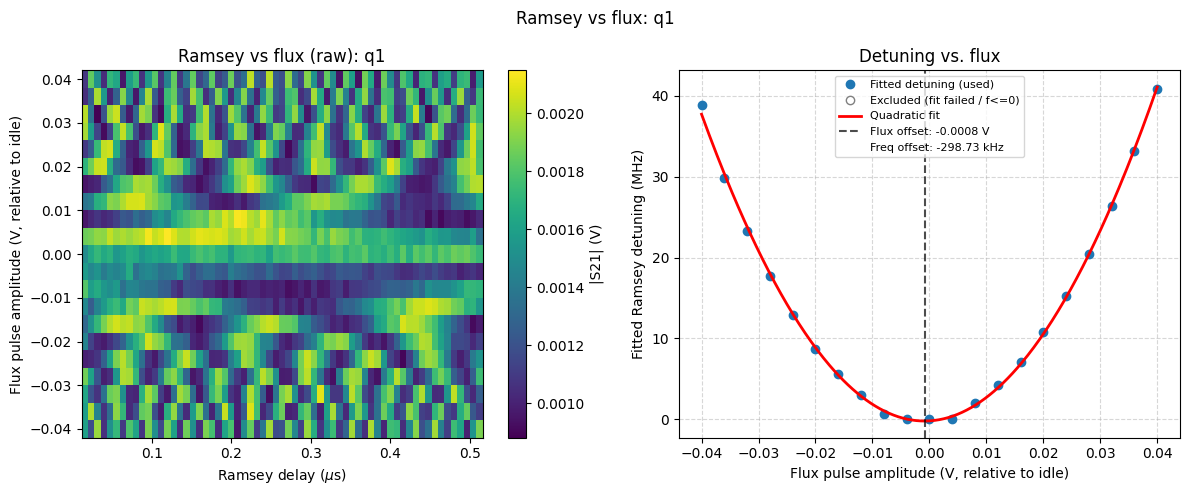

In [15]:
if PLOT_RESULTS:
    experiment.plot()

## Optional: apply flux + frequency corrections

In [16]:
APPLY_CORRECTIONS = True  # Applies both the flux-bias and f01 corrections together
SAVE_SELECTED_FLUX_BIASES = True

In [17]:
if APPLY_CORRECTIONS:
    # update_device() applies both the resolved idle flux-bias delta and the f01
    # frequency correction together, skipping any qubit whose fit failed.
    updated_qubits = experiment.update_device()
    if not updated_qubits:
        raise ValueError("No qubit has a successful fit -- nothing to apply.")

    live_biases = experiment.read_flux_biases()
    for qubit_name in updated_qubits:
        qubit = hardware_agent.quantum_device.get_element(qubit_name)
        print(f"{qubit_name}: live flux bias = {live_biases[qubit_name]:.6f} V")
        print(f"{qubit_name}: clock_freqs.f01 updated to {qubit.clock_freqs.f01 / 1e9:.9f} GHz")

    if SAVE_SELECTED_FLUX_BIASES:
        if FLUX_CONFIG is None:
            raise ValueError("Set FLUX_CONFIG to a file path before saving.")
        saved_flux_path = experiment.save_flux_biases(
            FLUX_CONFIG,
            {name: live_biases[name] for name in updated_qubits},
        )
        print(f"Saved flux operating points to {saved_flux_path}")

    if SAVE_FITTED_DEVICE is not None:
        saved_device_path = save_device_configuration(
            hardware_agent.quantum_device,
            SAVE_FITTED_DEVICE,
        )
        print(f"Updated device configuration saved to {saved_device_path}")

q1: live flux bias = 0.183244 V
q1: clock_freqs.f01 updated to 3.545976194 GHz
Saved flux operating points to /home/reny871224/qblox-measurement-nodes/config/flux_config_AS_QRC.json
Updated device configuration saved to /home/reny871224/qblox-measurement-nodes/config/dut_config_AS_QRC.json


In [ ]:
if PLOT_RESULTS and experiment.figures:
    save_result_figures(SESSION, dataset, EXPERIMENT_NAME, experiment.figures)
save_config_snapshot(SESSION, dataset, EXPERIMENT_NAME)


## Release hardware connection

In [ ]:
from qcodes.instrument import Instrument

Instrument.close_all()